In [1]:
# Install necessary libraries
!pip install shap -q

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import shap
import joblib

In [3]:
# Load data and display head
df = pd.read_csv("/content/customer_segments.csv")

df.head()

,customer_unique_id,customer_state,frequency,recency_days,monetary_value,avg_order_value,total_items_purchased,avg_freight_cost,total_orders,delivered_order_rate,...,unique_categories,unique_sellers,avg_review_score,good_review_rate,bad_review_rate,avg_installments,total_payment_value,weekend_purchase_ratio,monthly_purchase_frequency,cluster
0,861eff4711a542e4b93843c6dd7febb0,SP,1,519,124.99,124.99,1,21.88,1,1.0,...,1,1,4.0,1.0,0.0,2.0,146.87,0.0,0.041667,0
1,290c77bc529b7ac935b93aa66c333dc3,SP,1,277,289.00,289.00,1,46.48,1,1.0,...,1,1,5.0,1.0,0.0,8.0,335.48,0.0,0.041667,0
2,060e732b5b29e8181a18229c7b0b2b5e,SP,1,151,139.94,139.94,1,17.79,1,1.0,...,1,1,5.0,1.0,0.0,7.0,157.73,1.0,0.041667,0
3,259dac757896d24d7702b9acbbff3f3c,SP,1,218,149.94,149.94,1,23.36,1,1.0,...,1,1,5.0,1.0,0.0,1.0,173.30,0.0,0.041667,0
4,345ecd01c38d18a9036ed96c73b8d066,SP,1,80,230.00,230.00,1,22.25,1,1.0,...,1,1,5.0,1.0,0.0,8.0,252.25,1.0,0.041667,0


In [4]:
# Define high-value customers based on monetary value threshold
threshold = (
    df["monetary_value"]
    .quantile(0.75)
)

df["high_value_customer"] = (
    df["monetary_value"]
    > threshold
).astype(int)

In [5]:
# Define columns to drop
drop_cols = [
    "customer_unique_id",
    "monetary_value",
    "total_payment_value",
    "avg_order_value"
]

In [6]:
# Prepare features (X) and target (y)
X = df.drop(
    columns=
    drop_cols +
    ["high_value_customer"],
    errors="ignore"
)

y = df["high_value_customer"]

In [7]:
# Apply one-hot encoding to 'customer_state'
X = pd.get_dummies(
    X,
    columns=["customer_state"],
    drop_first=True
)

In [8]:
# Train XGBoost Classifier model
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
# Initialize SHAP explainer and calculate SHAP values
explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X
)

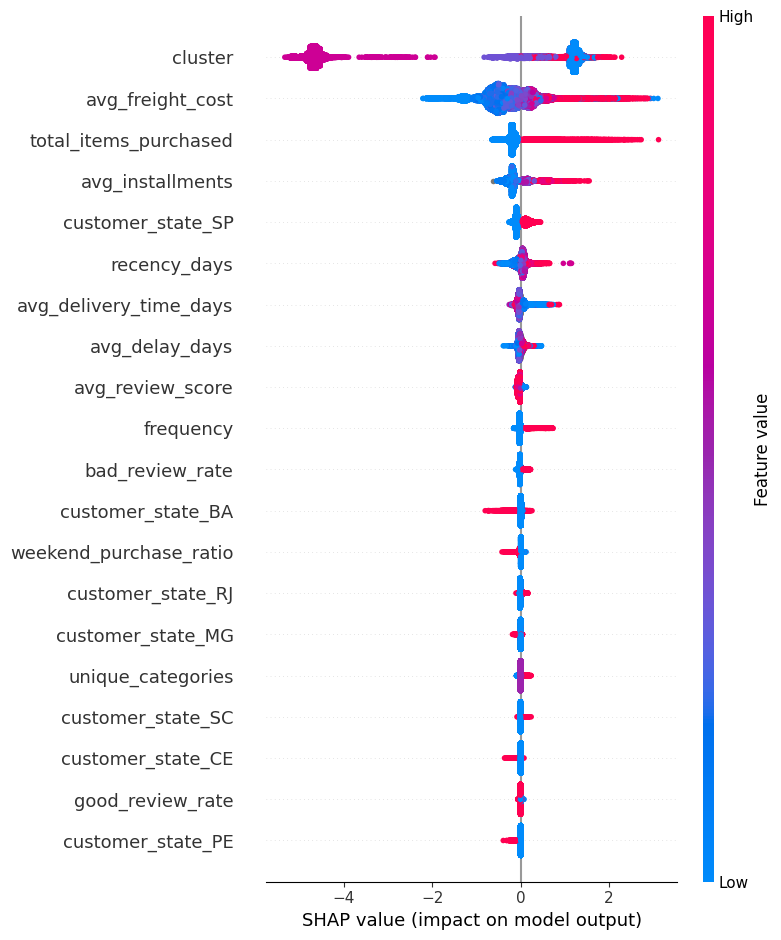

In [10]:
# Plot SHAP summary plot
shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.tight_layout()

plt.show()

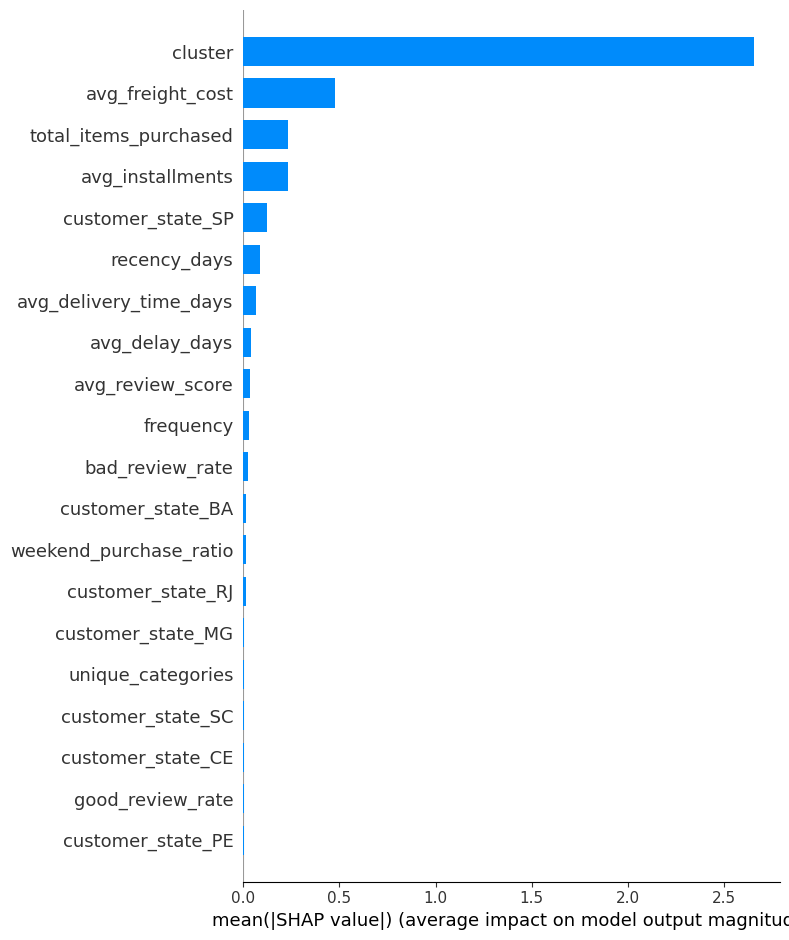

In [11]:
# Plot SHAP bar summary plot
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.show()

In [12]:
# Plot SHAP waterfall plot for a specific customer
customer_idx = 10

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=explainer.expected_value,
        data=X.iloc[customer_idx],
        feature_names=X.columns
    )
)

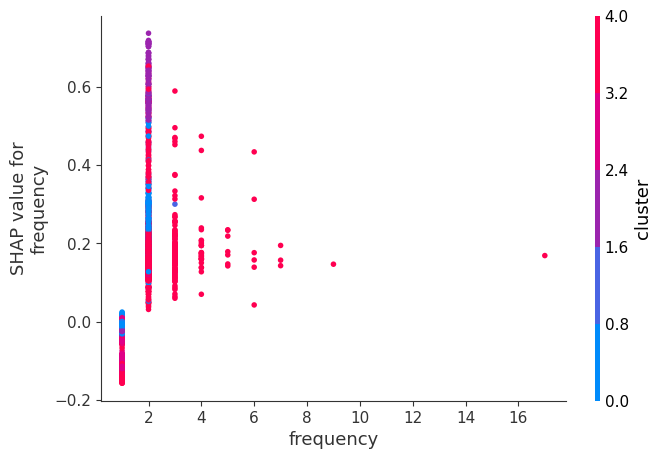

In [13]:
# Plot SHAP dependence plot for 'frequency'
shap.dependence_plot(
    "frequency",
    shap_values,
    X
)

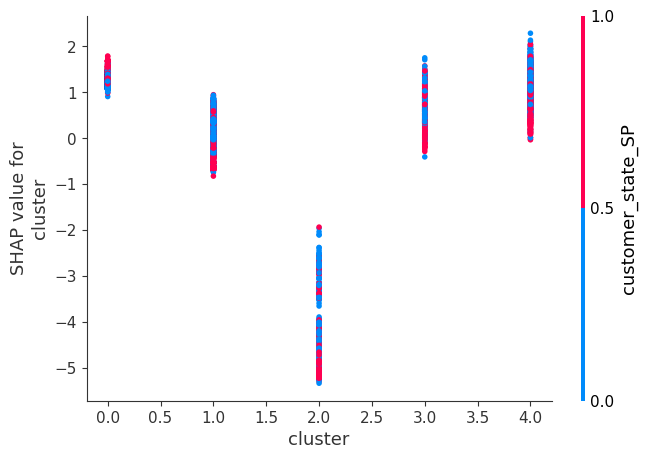

In [14]:
# Plot SHAP dependence plot for 'cluster'
shap.dependence_plot(
    "cluster",
    shap_values,
    X
)

In [15]:
# Save the trained model
joblib.dump(
    model,
    "high_value_explainability_model.pkl"
)

['high_value_explainability_model.pkl']